In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import r2_score, mean_squared_error

In [2]:
train = pd.read_csv('train_energy_data.csv')
test = pd.read_csv('test_energy_data.csv')

train.head()

,Building Type,Square Footage,Number of Occupants,Appliances Used,Average Temperature,Day of Week,Energy Consumption
0,Residential,7063,76,10,29.84,Weekday,2713.95
1,Commercial,44372,66,45,16.72,Weekday,5744.99
2,Industrial,19255,37,17,14.30,Weekend,4101.24
3,Residential,13265,14,41,32.82,Weekday,3009.14
4,Commercial,13375,26,18,11.92,Weekday,3279.17


In [3]:
# Encode categorical columns
le_building = LabelEncoder()
le_day = LabelEncoder()

train['Building Type'] = le_building.fit_transform(train['Building Type'])
train['Day of Week'] = le_day.fit_transform(train['Day of Week'])

test['Building Type'] = le_building.transform(test['Building Type'])
test['Day of Week'] = le_day.transform(test['Day of Week'])

train.head()

,Building Type,Square Footage,Number of Occupants,Appliances Used,Average Temperature,Day of Week,Energy Consumption
0,2,7063,76,10,29.84,0,2713.95
1,0,44372,66,45,16.72,0,5744.99
2,1,19255,37,17,14.30,1,4101.24
3,2,13265,14,41,32.82,0,3009.14
4,0,13375,26,18,11.92,0,3279.17


In [4]:
# Features and target
feature_cols = ['Square Footage', 'Number of Occupants', 'Appliances Used', 'Average Temperature', 'Building Type', 'Day of Week']

X_train = train[feature_cols].values
y_train = train['Energy Consumption'].values

X_test = test[feature_cols].values
y_test = test['Energy Consumption'].values

In [5]:
# Scale features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [6]:
# Train linear regression
lr = LinearRegression()
lr.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [7]:
y_pred = lr.predict(X_test)

print('R2 Score :', round(r2_score(y_test, y_pred), 4))
print('RMSE     :', round(np.sqrt(mean_squared_error(y_test, y_pred)), 2))

R2 Score : 0.8142
RMSE     : 357.09


In [8]:
# Coefficients
print('Coefficients:', lr.coef_)
print('Intercept   :', lr.intercept_)

Coefficients: [ 726.42801703  299.83489146  287.14082968  -30.32876752 -210.17213965
  -19.67363992]
Intercept   : 4166.25257


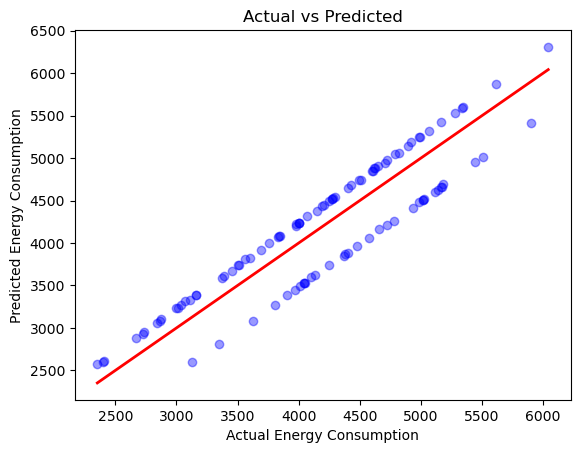

In [9]:
# Actual vs Predicted
plt.scatter(y_test, y_pred, alpha=0.4, color='b')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r-', linewidth=2)
plt.xlabel('Actual Energy Consumption')
plt.ylabel('Predicted Energy Consumption')
plt.title('Actual vs Predicted')
plt.show()

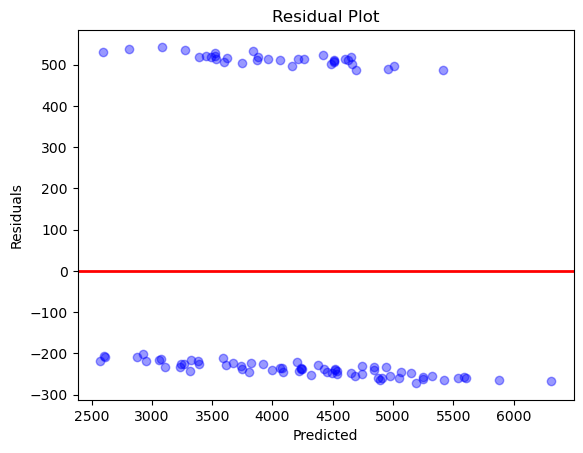

In [10]:
# Residuals
residuals = y_test - y_pred
plt.scatter(y_pred, residuals, alpha=0.4, color='b')
plt.axhline(0, color='r', linewidth=2)
plt.xlabel('Predicted')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.show()

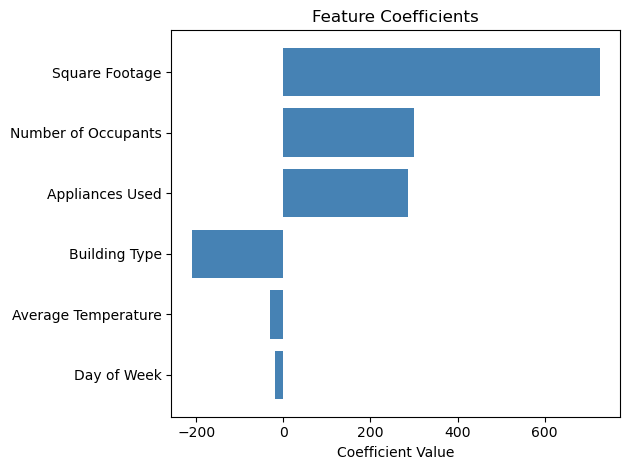

In [11]:
# Feature importance (by absolute coefficient)
coef_df = pd.DataFrame({'Feature': feature_cols, 'Coefficient': lr.coef_})
coef_df['Abs'] = coef_df['Coefficient'].abs()
coef_df = coef_df.sort_values('Abs', ascending=True)

plt.barh(coef_df['Feature'], coef_df['Coefficient'], color='steelblue')
plt.xlabel('Coefficient Value')
plt.title('Feature Coefficients')
plt.tight_layout()
plt.show()